# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import statistics as st
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss
from sklearn.linear_model import LinearRegression as lr

# Load Dataset

In [2]:
dat = pd.read_csv(r"E:\DATA FOR TEST\50 Startups\50_Startups.csv")
df = dat.copy()

# Exploratry Data Analysis 

In [11]:
print("Information\n", df.info())
print("\nDescribe\n", df.describe())
print("\nEmpty Values\n", df.isnull().sum())
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           44 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
Information
 None

Describe
            R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      44.000000
mean    73721.615600   121344.639600    211025.097800  112466.881364
std     45902.256482    28017.802755    122290.310726   43000.569645
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   81173.235000
50%     73051.080000   122699.795000    212716.240000  104145.345000
75%    10160

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# X Variable and Y Variable(Target Variable)

In [12]:
x = df["R&D Spend"].values
y = df["Profit"].values

# x = df.iloc[:, 0].values
# y = df.iloc[:, -1].values

# Train Test Split

In [13]:
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2)

# Reshaping x Data (only for Single Feature Linear Regression)

In [14]:
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# Feature Scaling

In [15]:
Scaler = ss()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)

# Linear Regresssion

In [16]:
# Modal initilization
regressor = lr()

# Modal Learning From Train Data SET
regressor.fit(x_train, y_train)

# Modal Predicting X Test Data
y_pred = regressor.predict(x_test)


# Visulation of Prediction and Test

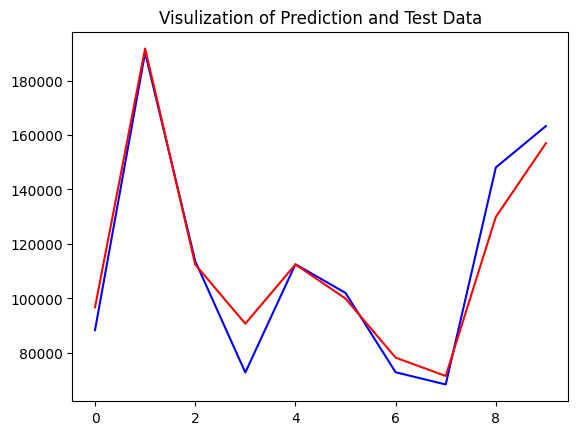

In [17]:
plt.plot(y_pred, color = 'Blue', label = "Prediction")
plt.plot(y_test, color = 'Red', label = "Test")
plt.title("Visulization of Prediction and Test Data")
plt.show()


# Result Matrix 

In [47]:
print(" -   - "*10)
print("Low Is Better\n")
print("Mean Absolute Error : \t", round(mae(y_test, Profit), 2))
print("Mean Squared Error : \t", round(mse(y_pred, y_test), 2))
print("Root Mean Squared Error : ", round(np.sqrt(mae(y_pred, y_test)), 2))
print(" -   - "*10)
print("High Is Better\n")

r2_Score = round(r2(y_pred, y_test),3)
print("R2 Score : \t", r2_Score)

n = x_test.shape[0]
k = x_test.shape[0]
Adj_R2 = 1 - (((1 - r2_Score) * (n-1))/(n-1-k))
print("Adjusted R2 Score : ", round((Adj_R2), 2))

 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
Low Is Better

Mean Absolute Error : 	 10743.62
Mean Squared Error : 	 224917120.76
Root Mean Squared Error :  103.65
 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
High Is Better

R2 Score : 	 0.836
Adjusted R2 Score :  2.48


In [61]:
# Initialize data (as numpy array)
Rand_data = np.array([[165349.2]])

# Reshape (now this works)
Rand_data = Rand_data.reshape(-1, 1)

# Feature scaling (IMPORTANT: use the SAME scaler fitted on training data)
Rand_data = Scaler.transform(Rand_data)

# Predict
val_pred = regressor.predict(Rand_data)

val_pred


array([187182.55457563])